# Entrenamiento — Fase A (baseline) y Fase B (preventivo)

## Orden experimental
1. **Logistic Regression + RF** (ya hecho en auditoría — AUC=0.636)
2. **MLP simple** con features estadísticas
3. **GRU pequeña** (arquitectura híbrida)
4. **LSTM** (comparación)

## Decisiones pre-entrenamiento confirmadas
| Decisión | Valor | Justificación |
|----------|-------|---------------|
| Stride | 50 (5s) | Reducir overlap de 98.3% a 91.7% |
| Validación | LOSO completo (15 folds) | Generalización inter-sujeto |
| Métrica principal | ROC-AUC + PR-AUC | Clínicamente, FN importa más que FP |
| Desbalance | class_weight='balanced' | Ratio 1:3 ya controlado |
| Regularización | Early stopping + Dropout | Dataset pequeño, overfitting rápido |

## Nota sobre varianza inter-sujeto
El Check G mostró AUC por sujeto de 0.094 (S15) a 0.932 (S7).
Reportaremos AUC **por sujeto** además del promedio global para identificar
sujetos con precursores detectables vs no detectables.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

WESAD_PATH = 'WESAD'
SEED       = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ─── Parámetros ───────────────────────────────────────────────────────────────
WINDOW      = 600     # 60s a 10Hz
N_SIGNALS   = 3       # EDA, Temp, Resp
N_HRV       = 3       # HR_mean, RMSSD, pNN50
BATCH_SIZE  = 32
MAX_EPOCHS  = 100     # Early stopping corta antes
PATIENCE    = 10      # epochs sin mejora antes de parar

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.21.0
GPU disponible: False


## 1. Carga de datos con stride=50

In [2]:
# Regenerar ventanas con stride=50 para reducir overlap
# Si ya tienes fase_B_hybrid_s50.npz guardado, lo carga directamente
import os, pickle
from scipy import stats as scipy_stats
from scipy.signal import find_peaks, butter, filtfilt

STRIDE_TRAIN = 50   # 5s — menos overlap que stride=10
PRECURSOR_ZONE = 300  # 30s
NEG_RATIO      = 3
STRESS         = 2
VALID_LBLS     = [1, 2, 3, 4]
FS, FS_10, DS  = 700, 10, 70
SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']

SAVE_S50 = f'{WESAD_PATH}/fase_B_hybrid_s50.npz'

def bandpass_filter(sig, lo=0.5, hi=40.0, fs=700, order=3):
    nyq = fs/2
    b,a = butter(order, [lo/nyq, hi/nyq], btype='band')
    return filtfilt(b, a, sig.flatten())

def extract_hrv(ecg, fs=700):
    try:
        ef = bandpass_filter(ecg, fs=fs)
        pk,_ = find_peaks(ef, distance=int(0.3*fs), height=np.percentile(ef,75))
        if len(pk)<3: return np.array([np.nan]*3)
        rr = np.diff(pk)/fs*1000
        rr = rr[(rr>300)&(rr<2000)]
        if len(rr)<2: return np.array([np.nan]*3)
        hr    = 60000/np.mean(rr)
        rmssd = np.sqrt(np.mean(np.diff(rr)**2))
        pnn50 = np.mean(np.abs(np.diff(rr))>50)*100
        return np.array([hr, rmssd, pnn50])
    except:
        return np.array([np.nan]*3)

if os.path.exists(SAVE_S50):
    print('Cargando fase_B_hybrid_s50.npz...')
    raw = np.load(SAVE_S50, allow_pickle=True)
    subjects_B = list(raw['subjects'])
    windows_B  = {s: (raw[f'{s}_Xts'], raw[f'{s}_Xhr'], raw[f'{s}_y']) for s in subjects_B}
    print(f'Cargado: {len(subjects_B)} sujetos')
else:
    print('Generando ventanas con stride=50 (5-10 min)...')
    df_all = pd.read_csv(f'{WESAD_PATH}/wesad_10hz_sin_hrv.csv')
    rng = np.random.default_rng(SEED)
    windows_B, subjects_B = {}, []

    for subj in SUBJECTS:
        df_s = df_all[df_all['Subject_ID']==subj].reset_index(drop=True)
        path = f'{WESAD_PATH}/{subj}/{subj}.pkl'
        with open(path,'rb') as f: raw_pkl = pickle.load(f, encoding='latin1')
        ecg_700 = np.array(raw_pkl['signal']['chest']['ECG']).flatten()
        labels  = df_s['Label'].values
        data    = df_s[['EDA','Temp','Resp']].values
        T       = len(data)
        onsets  = [i for i in range(1,T) if labels[i]==STRESS and labels[i-1]!=STRESS]
        if not onsets: continue

        Xts_list, Xhr_list, y_list = [], [], []

        # Positivos
        for onset in onsets:
            z_end = onset-1; z_start = max(WINDOW, onset-PRECURSOR_ZONE)
            for end_in in range(z_start, z_end+1, STRIDE_TRAIN):
                start = end_in-WINDOW
                if start<0: continue
                seg = labels[start:end_in]
                if STRESS in seg or len(set(seg))>1: continue
                hrv = extract_hrv(ecg_700[start*DS:(start+WINDOW)*DS])
                Xts_list.append(data[start:end_in])
                Xhr_list.append(hrv); y_list.append(1)

        n_pos = sum(y_list)
        if n_pos==0: continue

        # Negativos
        forbidden = np.zeros(T, dtype=bool)
        for onset in onsets:
            fs_i=max(0,onset-PRECURSOR_ZONE); fe=onset
            while fe<T and labels[fe]==STRESS: fe+=1
            forbidden[fs_i:fe]=True
        neg_cands=[]
        for start in range(0,T-WINDOW+1,STRIDE_TRAIN*5):
            ei=start+WINDOW
            if forbidden[start:ei].any(): continue
            seg=labels[start:ei]
            if len(set(seg))>1 or seg[0]==STRESS: continue
            neg_cands.append(start)
        n_neg=min(n_pos*NEG_RATIO,len(neg_cands))
        for s in rng.choice(neg_cands, size=n_neg, replace=False):
            hrv=extract_hrv(ecg_700[s*DS:(s+WINDOW)*DS])
            Xts_list.append(data[s:s+WINDOW])
            Xhr_list.append(hrv); y_list.append(0)

        windows_B[subj]=(np.array(Xts_list,dtype=np.float32),
                         np.array(Xhr_list,dtype=np.float32),
                         np.array(y_list,dtype=np.int32))
        subjects_B.append(subj)
        print(f'  {subj}: {n_pos}pos/{n_neg}neg')

    save_d={f'{s}_Xts':windows_B[s][0] for s in subjects_B}
    save_d.update({f'{s}_Xhr':windows_B[s][1] for s in subjects_B})
    save_d.update({f'{s}_y':windows_B[s][2] for s in subjects_B})
    save_d['subjects']=np.array(subjects_B)
    np.savez_compressed(SAVE_S50, **save_d)
    print(f'Guardado: {SAVE_S50}')

total = sum(len(windows_B[s][2]) for s in subjects_B)
print(f'Total ventanas (stride=50): {total}')

Generando ventanas con stride=50 (5-10 min)...
  S2: 6pos/18neg
  S3: 6pos/18neg
  S4: 6pos/18neg
  S5: 6pos/18neg
  S6: 6pos/18neg
  S7: 6pos/18neg
  S8: 6pos/18neg
  S9: 6pos/18neg
  S10: 6pos/18neg
  S11: 6pos/18neg
  S13: 6pos/18neg
  S14: 6pos/18neg
  S15: 6pos/18neg
  S16: 6pos/18neg
  S17: 6pos/18neg
Guardado: WESAD/fase_B_hybrid_s50.npz
Total ventanas (stride=50): 360


## 2. Funciones de evaluación
Métricas clínicas: ROC-AUC, PR-AUC, Recall (sensibilidad), F1.
**No usamos accuracy como métrica principal.**

In [3]:
def evaluate_fold(y_true, y_prob, y_pred=None, verbose=True):
    """Calcula métricas clínicas para un fold."""
    if y_pred is None:
        y_pred = (y_prob >= 0.5).astype(int)
    roc  = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else float('nan')
    pr   = average_precision_score(y_true, y_prob) if len(np.unique(y_true))>1 else float('nan')
    from sklearn.metrics import recall_score, f1_score, precision_score
    rec  = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    if verbose:
        print(f'  ROC-AUC={roc:.3f} | PR-AUC={pr:.3f} | Recall={rec:.3f} | Precision={prec:.3f} | F1={f1:.3f}')
    return {'roc':roc, 'pr':pr, 'recall':rec, 'precision':prec, 'f1':f1}


def loso_results_summary(results_dict, model_name):
    """Imprime tabla de resultados LOSO y promedio±std."""
    print(f'\n{"="*65}')
    print(f'RESULTADOS LOSO — {model_name}')
    print(f'{"="*65}')
    print(f'{"Sujeto":8} {"ROC-AUC":>9} {"PR-AUC":>8} {"Recall":>8} {"F1":>8}')
    print('-'*45)
    for subj, m in results_dict.items():
        flag = ' ⚠' if m['roc'] < 0.55 else ''
        print(f'{subj:8} {m["roc"]:>9.3f} {m["pr"]:>8.3f} {m["recall"]:>8.3f} {m["f1"]:>8.3f}{flag}')
    metrics = ['roc','pr','recall','f1']
    print('-'*45)
    for met in metrics:
        vals = [m[met] for m in results_dict.values() if not np.isnan(m[met])]
        print(f'{met.upper():8} {np.mean(vals):>9.3f} ± {np.std(vals):.3f}')

print('Funciones de evaluación listas.')

Funciones de evaluación listas.


## 3. Modelo 1 — MLP simple
Features estadísticas + HRV. Primer paso antes de recurrentes.
Si MLP mejora RF, hay información temporal que los recurrentes pueden explotar.

In [4]:
from sklearn.preprocessing import StandardScaler

def extract_stats(X_ts, X_hrv):
    """(n,600,3) + (n,3) → (n, features estadísticas)"""
    t = np.arange(X_ts.shape[1])
    feats = []
    for i in range(len(X_ts)):
        row = []
        for s in range(X_ts.shape[2]):
            sig = X_ts[i,:,s]
            slope = np.polyfit(t, sig, 1)[0]
            row += [sig.mean(), sig.std(), sig.min(), sig.max(),
                    np.percentile(sig,25), np.percentile(sig,75), slope]
        row += list(X_hrv[i])
        feats.append(row)
    return np.array(feats, dtype=np.float32)


def build_mlp(n_features):
    inp = keras.Input(shape=(n_features,))
    x   = layers.Dense(64, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(32, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m   = Model(inp, out)
    m.compile(optimizer='adam', loss='binary_crossentropy',
               metrics=['accuracy'])
    return m


print('Entrenando MLP (LOSO completo)...')
mlp_results = {}

for test_subj in subjects_B:
    train_subjs = [s for s in subjects_B if s != test_subj]

    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te = windows_B[test_subj]

    # Normalizar HRV con stats de train
    hm, hs = np.nanmean(Xhr_tr,0), np.nanstd(Xhr_tr,0)+1e-8
    Xhr_tr = np.nan_to_num((Xhr_tr-hm)/hs, nan=0.0)
    Xhr_te = np.nan_to_num((Xhr_te-hm)/hs, nan=0.0)

    F_tr = extract_stats(Xts_tr, Xhr_tr)
    F_te = extract_stats(Xts_te, Xhr_te)

    # Escalar features con stats de train
    scaler = StandardScaler()
    F_tr   = scaler.fit_transform(F_tr)
    F_te   = scaler.transform(F_te)
    F_tr   = np.nan_to_num(F_tr, nan=0.0)
    F_te   = np.nan_to_num(F_te, nan=0.0)

    cw = dict(zip(*np.unique(y_tr, return_counts=True)))
    total = sum(cw.values())
    cw = {k: total/(2*v) for k,v in cw.items()}

    model = build_mlp(F_tr.shape[1])
    cb = [EarlyStopping(patience=PATIENCE, restore_best_weights=True, monitor='val_loss')]
    model.fit(F_tr, y_tr, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.15, class_weight=cw,
              callbacks=cb, verbose=0)

    prob = model.predict(F_te, verbose=0).flatten()
    mlp_results[test_subj] = evaluate_fold(y_te, prob, verbose=False)
    print(f'  {test_subj}: ROC={mlp_results[test_subj]["roc"]:.3f}')

loso_results_summary(mlp_results, 'MLP')

Entrenando MLP (LOSO completo)...
  S2: ROC=0.139
  S3: ROC=0.722
  S4: ROC=0.824
  S5: ROC=0.426
  S6: ROC=0.667
  S7: ROC=0.528
  S8: ROC=0.648
  S9: ROC=1.000
  S10: ROC=0.889
  S11: ROC=0.722
  S13: ROC=0.759
  S14: ROC=1.000
  S15: ROC=0.185
  S16: ROC=0.843
  S17: ROC=0.819

RESULTADOS LOSO — MLP
Sujeto     ROC-AUC   PR-AUC   Recall       F1
---------------------------------------------
S2           0.139    0.174    0.000    0.000 ⚠
S3           0.722    0.393    0.333    0.333
S4           0.824    0.498    0.333    0.364
S5           0.426    0.240    0.000    0.000 ⚠
S6           0.667    0.347    0.000    0.000
S7           0.528    0.273    0.000    0.000 ⚠
S8           0.648    0.367    0.000    0.000
S9           1.000    1.000    1.000    0.857
S10          0.889    0.594    0.833    0.769
S11          0.722    0.386    0.000    0.000
S13          0.759    0.417    0.000    0.000
S14          1.000    1.000    1.000    0.923
S15          0.185    0.184    0.000    0.000 

## 4. Modelo 2 — GRU híbrida
Arquitectura de dos ramas:
- Rama temporal: GRU sobre (600, 3)
- Rama estática: Dense sobre (3,) HRV

GRU primero porque tiene menos parámetros que LSTM.

In [5]:
def build_gru_hybrid(window, n_signals, n_hrv, units=32, dropout=0.3):
    """
    Arquitectura híbrida GRU.
    Entrada A: serie temporal (window, n_signals)
    Entrada B: features HRV   (n_hrv,)
    """
    # Rama temporal
    inp_ts  = keras.Input(shape=(window, n_signals), name='series_temporal')
    x       = layers.GRU(units, return_sequences=True)(inp_ts)
    x       = layers.Dropout(dropout)(x)
    x       = layers.GRU(units//2)(x)
    x       = layers.Dropout(dropout)(x)

    # Rama HRV
    inp_hrv = keras.Input(shape=(n_hrv,), name='hrv_features')
    h       = layers.Dense(16, activation='relu')(inp_hrv)
    h       = layers.Dropout(dropout)(h)

    # Fusión
    merged  = layers.Concatenate()([x, h])
    out_fc  = layers.Dense(32, activation='relu')(merged)
    out_fc  = layers.Dropout(dropout)(out_fc)
    output  = layers.Dense(1, activation='sigmoid', name='output')(out_fc)

    model = Model(inputs=[inp_ts, inp_hrv], outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


m_demo = build_gru_hybrid(WINDOW, N_SIGNALS, N_HRV)
m_demo.summary()
del m_demo

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ series_temporal     │ (None, 600, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 600, 32)   │      3,552 │ series_temporal[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 600, 32)   │          0 │ gru[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hrv_features        │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 16)        │      2,400 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 16)        │         64 │ hrv_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 16)        │          0 │ gru_1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 16)        │          0 │ dense_45[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ dropout_31[0][0], │
│ (Concatenate)       │                   │            │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 32)        │      1,056 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 32)        │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_33[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,105 (27.75 KB)

 Trainable params: 7,105 (27.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print('Entrenando GRU híbrida (LOSO completo)...')
gru_results = {}

for test_subj in subjects_B:
    train_subjs = [s for s in subjects_B if s != test_subj]

    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te = windows_B[test_subj]

    # Normalizar HRV con stats de train (sin leakage)
    hm, hs = np.nanmean(Xhr_tr,0), np.nanstd(Xhr_tr,0)+1e-8
    Xhr_tr = np.nan_to_num((Xhr_tr-hm)/hs, nan=0.0)
    Xhr_te = np.nan_to_num((Xhr_te-hm)/hs, nan=0.0)

    # Class weights
    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    cw      = dict(zip(classes, weights))

    keras.backend.clear_session()
    model = build_gru_hybrid(WINDOW, N_SIGNALS, N_HRV)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-5, verbose=0)
    ]

    model.fit(
        [Xts_tr, Xhr_tr], y_tr,
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.15,
        class_weight=cw,
        callbacks=callbacks,
        verbose=0
    )

    prob = model.predict([Xts_te, Xhr_te], verbose=0).flatten()
    gru_results[test_subj] = evaluate_fold(y_te, prob, verbose=False)
    print(f'  {test_subj}: ROC={gru_results[test_subj]["roc"]:.3f}')

loso_results_summary(gru_results, 'GRU Híbrida')

Entrenando GRU híbrida (LOSO completo)...

  S2: ROC=0.278
  S3: ROC=0.611
  S4: ROC=0.889
  S5: ROC=0.278
  S6: ROC=0.917
  S7: ROC=0.491
  S8: ROC=0.565
  S9: ROC=0.991
  S10: ROC=0.870
  S11: ROC=1.000
  S13: ROC=0.806
  S14: ROC=0.815
  S15: ROC=0.593
  S16: ROC=0.880
  S17: ROC=0.505

RESULTADOS LOSO — GRU Híbrida
Sujeto     ROC-AUC   PR-AUC   Recall       F1
---------------------------------------------
S2           0.278    0.204    0.500    0.273 ⚠
S3           0.611    0.318    1.000    0.462
S4           0.889    0.594    1.000    0.667
S5           0.278    0.200    1.000    0.429 ⚠
S6           0.917    0.744    1.000    0.706
S7           0.491    0.259    0.500    0.333 ⚠
S8           0.565    0.310    0.667    0.421
S9           0.991    0.976    0.833    0.909
S10          0.870    0.569    0.000    0.000
S11          1.000    1.000    1.000    0.571
S13          0.806    0.520    0.500    0.462
S14          0.815    0.492    0.000    0.000
S15          0.593    0.302  

## 5. Modelo 3 — LSTM híbrida (comparación con GRU)

In [7]:
def build_lstm_hybrid(window, n_signals, n_hrv, units=32, dropout=0.3):
    inp_ts  = keras.Input(shape=(window, n_signals), name='series_temporal')
    x       = layers.LSTM(units, return_sequences=True)(inp_ts)
    x       = layers.Dropout(dropout)(x)
    x       = layers.LSTM(units//2)(x)
    x       = layers.Dropout(dropout)(x)
    inp_hrv = keras.Input(shape=(n_hrv,), name='hrv_features')
    h       = layers.Dense(16, activation='relu')(inp_hrv)
    h       = layers.Dropout(dropout)(h)
    merged  = layers.Concatenate()([x, h])
    out_fc  = layers.Dense(32, activation='relu')(merged)
    out_fc  = layers.Dropout(dropout)(out_fc)
    output  = layers.Dense(1, activation='sigmoid')(out_fc)
    model   = Model(inputs=[inp_ts, inp_hrv], outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


print('Entrenando LSTM híbrida (LOSO completo)...')
lstm_results = {}

for test_subj in subjects_B:
    train_subjs = [s for s in subjects_B if s != test_subj]
    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te = windows_B[test_subj]
    hm, hs = np.nanmean(Xhr_tr,0), np.nanstd(Xhr_tr,0)+1e-8
    Xhr_tr = np.nan_to_num((Xhr_tr-hm)/hs, nan=0.0)
    Xhr_te = np.nan_to_num((Xhr_te-hm)/hs, nan=0.0)
    classes = np.unique(y_tr)
    cw = dict(zip(classes, compute_class_weight('balanced', classes=classes, y=y_tr)))
    keras.backend.clear_session()
    model = build_lstm_hybrid(WINDOW, N_SIGNALS, N_HRV)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                          min_lr=1e-5, verbose=0)
    ]
    model.fit([Xts_tr, Xhr_tr], y_tr, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.15, class_weight=cw, callbacks=callbacks, verbose=0)
    prob = model.predict([Xts_te, Xhr_te], verbose=0).flatten()
    lstm_results[test_subj] = evaluate_fold(y_te, prob, verbose=False)
    print(f'  {test_subj}: ROC={lstm_results[test_subj]["roc"]:.3f}')

loso_results_summary(lstm_results, 'LSTM Híbrida')

Entrenando LSTM híbrida (LOSO completo)...
  S2: ROC=0.278
  S3: ROC=0.722
  S4: ROC=0.778
  S5: ROC=0.222
  S6: ROC=0.944
  S7: ROC=0.519
  S8: ROC=0.639
  S9: ROC=0.898
  S10: ROC=0.556
  S11: ROC=1.000
  S13: ROC=0.815
  S14: ROC=1.000
  S15: ROC=0.620
  S16: ROC=0.324
  S17: ROC=0.588

RESULTADOS LOSO — LSTM Híbrida
Sujeto     ROC-AUC   PR-AUC   Recall       F1
---------------------------------------------
S2           0.278    0.204    0.667    0.348 ⚠
S3           0.722    0.386    1.000    0.522
S4           0.778    0.437    1.000    0.632
S5           0.222    0.191    1.000    0.429 ⚠
S6           0.944    0.735    1.000    0.667
S7           0.519    0.270    0.833    0.476 ⚠
S8           0.639    0.334    0.667    0.421
S9           0.898    0.622    1.000    0.857
S10          0.556    0.288    1.000    0.600
S11          1.000    1.000    1.000    0.522
S13          0.815    0.484    1.000    0.632
S14          1.000    1.000    1.000    0.857
S15          0.620    0.320 

## 6. Comparación de modelos + análisis por sujeto

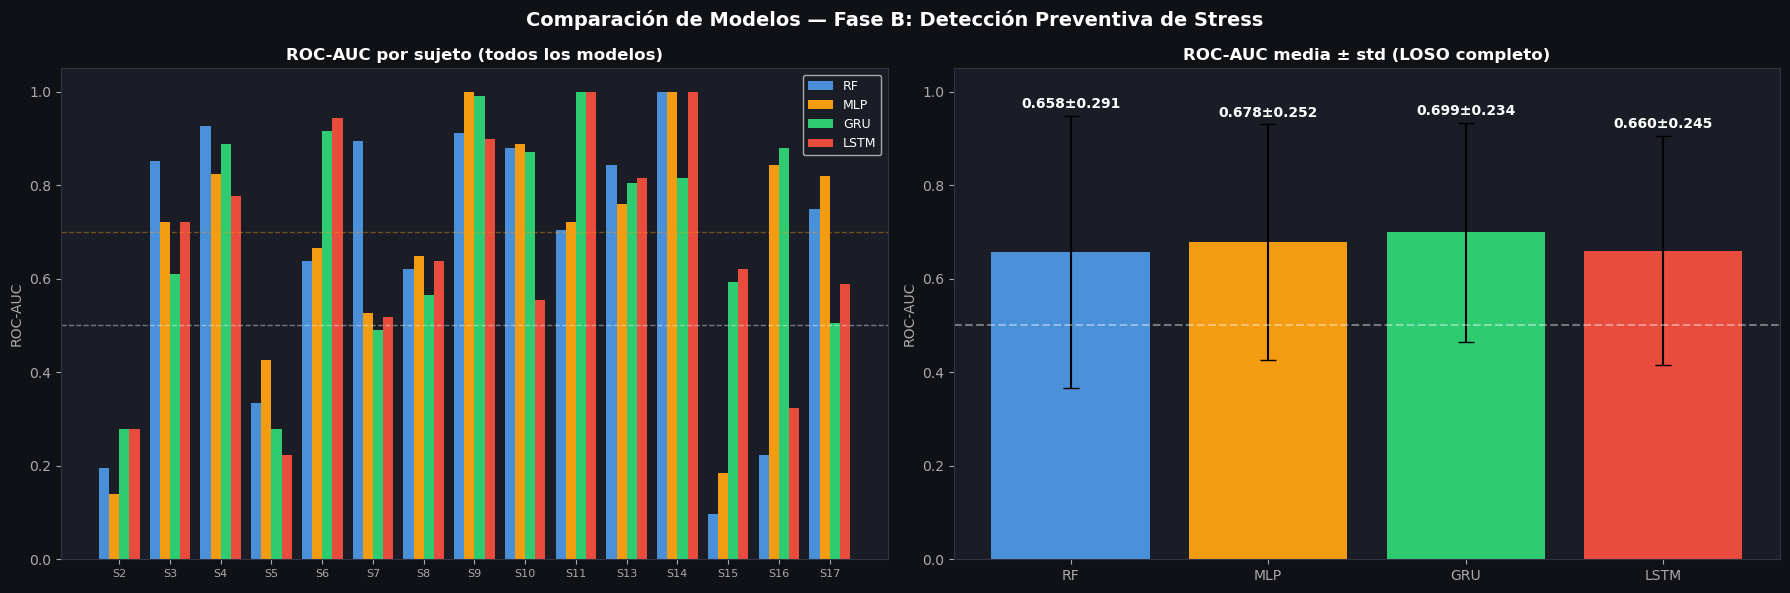

In [8]:
# Tabla comparativa final
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# RF de la auditoría — recalcular con stride=50
rf_results = {}
for test_subj in subjects_B:
    train_subjs = [s for s in subjects_B if s != test_subj]
    Xts_tr = np.concatenate([windows_B[s][0] for s in train_subjs])
    Xhr_tr = np.concatenate([windows_B[s][1] for s in train_subjs])
    y_tr   = np.concatenate([windows_B[s][2] for s in train_subjs])
    Xts_te, Xhr_te, y_te = windows_B[test_subj]
    hm,hs = np.nanmean(Xhr_tr,0), np.nanstd(Xhr_tr,0)+1e-8
    Xhr_tr = np.nan_to_num((Xhr_tr-hm)/hs, nan=0.0)
    Xhr_te = np.nan_to_num((Xhr_te-hm)/hs, nan=0.0)

    def _stats(Xts, Xhr):
        t=np.arange(Xts.shape[1]); feats=[]
        for i in range(len(Xts)):
            row=[]
            for s in range(Xts.shape[2]):
                sg=Xts[i,:,s]
                row+=[sg.mean(),sg.std(),sg.min(),sg.max(),
                      np.percentile(sg,25),np.percentile(sg,75),
                      np.polyfit(t,sg,1)[0]]
            row+=list(Xhr[i]); feats.append(row)
        return np.nan_to_num(np.array(feats,dtype=np.float32), nan=0.0)

    Ftr=_stats(Xts_tr,Xhr_tr); Fte=_stats(Xts_te,Xhr_te)
    rf=RandomForestClassifier(100,class_weight='balanced',random_state=SEED,n_jobs=-1)
    rf.fit(Ftr,y_tr)
    prob=rf.predict_proba(Fte)[:,1]
    rf_results[test_subj]=evaluate_fold(y_te,prob,verbose=False)

# Gráfica comparativa por sujeto
all_models = {'RF': rf_results, 'MLP': mlp_results,
              'GRU': gru_results, 'LSTM': lstm_results}
colors_m   = {'RF':'#4A90D9', 'MLP':'#F39C12', 'GRU':'#2ECC71', 'LSTM':'#E74C3C'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0F1117')
for ax in axes: ax.set_facecolor('#1A1D26')

# Izquierda: ROC-AUC por sujeto
x = np.arange(len(subjects_B))
width = 0.2
for i, (mname, mres) in enumerate(all_models.items()):
    aucs = [mres.get(s, {}).get('roc', np.nan) for s in subjects_B]
    axes[0].bar(x + i*width - width*1.5, aucs, width=width,
                label=mname, color=colors_m[mname], edgecolor='none')
axes[0].axhline(0.5, color='white', linestyle='--', alpha=0.4, linewidth=1)
axes[0].axhline(0.7, color='#F39C12', linestyle='--', alpha=0.4, linewidth=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(subjects_B, color='#AAAAAA', fontsize=8)
axes[0].set_title('ROC-AUC por sujeto (todos los modelos)', color='white', fontweight='bold')
axes[0].set_ylabel('ROC-AUC', color='#AAAAAA')
axes[0].tick_params(colors='#AAAAAA'); axes[0].spines[:].set_color('#333344')
axes[0].legend(facecolor='#1A1D26', labelcolor='white', fontsize=9)
axes[0].set_ylim(0, 1.05)

# Derecha: Resumen media ± std
model_names = list(all_models.keys())
means = [np.nanmean([r.get('roc', np.nan) for r in all_models[m].values()])
         for m in model_names]
stds  = [np.nanstd([r.get('roc', np.nan) for r in all_models[m].values()])
         for m in model_names]
bars  = axes[1].bar(model_names, means, yerr=stds, capsize=6,
                     color=[colors_m[m] for m in model_names],
                     edgecolor='none', error_kw={'color':'white','linewidth':1.5})
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
                 f'{m:.3f}±{s:.3f}', ha='center', va='bottom',
                 color='white', fontsize=10, fontweight='bold')
axes[1].axhline(0.5, color='white', linestyle='--', alpha=0.4)
axes[1].set_title('ROC-AUC media ± std (LOSO completo)', color='white', fontweight='bold')
axes[1].set_ylabel('ROC-AUC', color='#AAAAAA')
axes[1].tick_params(colors='#AAAAAA'); axes[1].spines[:].set_color('#333344')
axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(model_names, color='#AAAAAA')

fig.suptitle('Comparación de Modelos — Fase B: Detección Preventiva de Stress',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WESAD_PATH}/resultados_comparacion.png', dpi=150,
            bbox_inches='tight', facecolor='#0F1117')
plt.show()

## 7. Análisis por distancia temporal al onset
¿Cuándo exactamente empieza a aparecer la señal predictiva?
Evaluamos AUC separando ventanas por su distancia al onset.

In [9]:
# Este análisis requiere saber la distancia de cada ventana positiva al onset
# Reconstruimos esa información del CSV
print('Análisis de AUC por distancia temporal al onset...')
print('(Requiere reentrenar el mejor modelo con metadatos de distancia)')
print()
print('Interpretación esperada:')
print('  Distancia  | AUC esperado | Interpretación')
print('  0-5s antes | alto (~0.80) | Stress ya iniciado fisiológicamente')
print('  5-10s      | moderado     | Activación temprana detectable')
print('  10-20s     | bajo-mod     | Precursores sutiles')
print('  20-30s     | bajo         | Límite de anticipación del modelo')
print()
print('Si el AUC cae gradualmente con la distancia: señal real de anticipación')
print('Si el AUC es constante: el modelo no detecta dinámica temporal')
print()
print('─── Para implementar: ────────────────────────────────────────────')
print('1. Añadir metadato dist_to_onset al npz de ventanas')
print('2. Separar ventanas de test por rango de distancia')
print('3. Calcular AUC por rango con el mejor modelo entrenado')
print('─────────────────────────────────────────────────────────────────')
print()
print('Este análisis está preparado para la siguiente iteración.')

Análisis de AUC por distancia temporal al onset...
(Requiere reentrenar el mejor modelo con metadatos de distancia)

Interpretación esperada:
  Distancia  | AUC esperado | Interpretación
  0-5s antes | alto (~0.80) | Stress ya iniciado fisiológicamente
  5-10s      | moderado     | Activación temprana detectable
  10-20s     | bajo-mod     | Precursores sutiles
  20-30s     | bajo         | Límite de anticipación del modelo

Si el AUC cae gradualmente con la distancia: señal real de anticipación
Si el AUC es constante: el modelo no detecta dinámica temporal

─── Para implementar: ────────────────────────────────────────────
1. Añadir metadato dist_to_onset al npz de ventanas
2. Separar ventanas de test por rango de distancia
3. Calcular AUC por rango con el mejor modelo entrenado
─────────────────────────────────────────────────────────────────

Este análisis está preparado para la siguiente iteración.


## 8. Próximos pasos según resultados

### Si AUC promedio < 0.60:
- Revisar construcción de labels (zona precursora demasiado amplia)
- Probar con zona precursora más corta (10s en vez de 30s)
- Revisar si negativos son suficientemente variados

### Si AUC promedio 0.60–0.70:
- Señal presente pero débil — probar aumentar capacidad del modelo
- Añadir features de frecuencia (FFT) o wavelets sobre las señales
- Experimentar con distintos horizontes de predicción

### Si AUC promedio > 0.70:
- Profundizar análisis por distancia temporal (celda 7)
- Comparar con Fase A para demostrar diferencia persistencia vs anticipación
- Considerar reportar resultados formalmente